In [1]:
!pip install numpy tensorflow pandas matplotlib scikit-learn

^C


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.6.1 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.


Importar las dependencias

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.16.1
NumPy version: 1.26.4


# GRU desde cero

In [4]:
class GRUFromScratch:
    def __init__(self, input_size, hidden_size, output_size, learning_rate = 0.01):
        """Inicializa los parámetros de la red GRU

        Args:
            input_size (_type_): dimensionalidad de la entrada(feature)
            hidden_size (_type_): Número de unidades ocultas
            output_size (_type_): Dimensionalidad de la salida
            learning_rate (float, optional): Tasa de aprendizaje. Por defecto 0.01.
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = learning_rate
        
        # Inicialización de pesos con distribución normal
        sigma = 0.01
        
        # Pesos para la puerta de actualización (update gate)
        self.W_xz = np.random.randn(input_size, hidden_size) * sigma # [X, H]
        self.W_hz = np.random.randn(hidden_size, hidden_size) * sigma # [H, H]
        self.b_z = np.zeros((1, hidden_size)) # [1, H]
        
        # Pesos para la puerta de reinicio (reset gate)
        self.W_xr = np.random.randn(input_size, hidden_size) * sigma # [X, H]
        self.W_hr = np.random.randn(hidden_size, hidden_size) * sigma # [H, H]
        self.b_r = np.zeros((1, hidden_size)) # [1, H]
        
        # Pesos para el estado candidato (candidate hidden state)
        self.W_xh = np.random.randn(input_size, hidden_size) * sigma # [X, H]
        self.W_hh = np.random.randn(hidden_size, hidden_size) * sigma # [H, H]
        self.b_h = np.zeros((1, hidden_size)) # [1, H]
        
        # Pesos para la capa de salida
        self.W_out = np.random.randn(hidden_size, output_size) * sigma # [H, Y]
        self.b_out = np.zeros((1, output_size)) # [1, Y]
        
    def sigmoid(self, x):
        """Función de activación sigmoide

        Args:
            x (_type_): Entrada a la función sigmoide

        Returns:
            _type_: Salida de la función sigmoide
        """
        return 1 / (1 + np.exp(-x))
    
    def tanh(self, x):
        """Función de activación tangente hiperbólica

        Args:
            x (_type_): Entrada a la función tanh

        Returns:
            _type_: Salida de la función tanh
        """
        return np.tanh(x)
    
    # Forward step (Un paso)
    def forward_step(self, x_t, h_prev):
        """Realiza un paso hacia adelante en la red GRU

        Args:
            x_t (_type_): Entrada en el tiempo t
            h_prev (_type_): Estado oculto en el tiempo t-1

        Returns:
            h_t: Nuevo estado oculto en el tiempo t
            y_t: Salida en el tiempo t
        """
        # Puerta de reinicio (reset gate)
        r_t = self.sigmoid(np.dot(x_t, self.W_xr) + np.dot(h_prev, self.W_hr) + self.b_r)
        
        # Puerta de actualización (update gate)
        z_t = self.sigmoid(np.dot(x_t, self.W_xz) + np.dot(h_prev, self.W_hz) + self.b_z)
        
        # Estado candidato (candidate hidden state)
        h_tilde = self.tanh(np.dot(x_t, self.W_xh) + np.dot(r_t * h_prev, self.W_hh) + self.b_h)
        
        # Nuevo estado oculto (new hidden state)
        h_t = (1 - z_t) * h_prev + z_t * h_tilde
        
        # Salida (output)
        y_t = np.dot(h_t, self.W_out) + self.b_out
        
        return h_t, y_t
    
    # Forward pass (Un pase completo)
    def forward(self, X):
        """
        Forward pass para toda la secuencia de entrada X

        Args:
            X (_type_): secuencia de entrada de forma (seq_len, input_size)
            
        Returns:
            h_states: estados ocultos en cada paso
            outputs: salidas en cada paso
        """
        seq_len = X.shape[0]
        h = np.zeros((1, self.hidden_size))  # Estado oculto inicial
        
        h_states = []
        outputs = []
        
        for t in range(seq_len):
            x_t = X[t:t+1, :] # Extraemos el paso t
            h, y = self.forward_step(x_t, h)
            h_states.append(h)
            outputs.append(y)

        return np.array(h_states), np.array(outputs)
    
    # Pérdida y entrenamiento
    def compute_loss(self, y_pred, y_true):
        """Calcula la pérdida MSE (Error cuadrático medio)

        Args:
            y_pred (_type_): Predicciones de la red
            y_true (_type_): Valores verdaderos

        Returns:
            _type_: Pérdida MSE
        """
        return np.mean((y_pred - y_true) ** 2)
    
    def train_step(self, X, y_true):
        """Realiza un paso de entrenamiento (forward + backward + update).
        NOTA IMPORTANTE: La retropropagación implementada es una versión simplificada debido a su complejidad.

        Args:
            X (_type_): secuencia de entrada
            y_true (_type_): valores verdaderos
        """
        # Forward pass
        h_states, y_pred = self.forward(X)
        
        # Calcular la pérdida
        loss = self.compute_loss(y_pred[-1], y_true)
        
        return loss, y_pred[-1]

Prueba

In [5]:
# Configuración de hiperparámetros

input_size = 3
hidden_size = 10
output_size = 1

# Crear el modelo

gru = GRUFromScratch(input_size, hidden_size, output_size)

# Datos de prueba: secuencia de 5 pasos
X_test = np.random.rand(5, input_size)  # Secuencia de 5 pasos con 3 características

# Forward pass
h_states, outputs = gru.forward(X_test)

print(f"Entrada shape: {X_test.shape}")
print(f"Estados ocultos shape: {h_states.shape}")
print(f"Salidas shape: {outputs.shape}")

Entrada shape: (5, 3)
Estados ocultos shape: (5, 1, 10)
Salidas shape: (5, 1, 1)


# GRU usando KERAS

In [6]:
# Importar keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [7]:
# Semilla para reproducibilidad
SEED = 666
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# Datos sintéticos para entrenamiento: 1000 secuencias de 10 pasos con 5 características
n_samples = 1000
seq_length = 10
n_features = 5

X = np.random.rand(n_samples, seq_length, n_features)

# Clasificación binaria: 0 o 2
y = np.random.randint(0, 2, (n_samples, 1))

In [9]:
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")

Shape de X: (1000, 10, 5), Shape de y: (1000, 1)


In [10]:
# Construir el modelo GRU con Keras

model = Sequential([
GRU(64, activation = 'tanh', recurrent_activation = 'sigmoid', return_sequences = True, input_shape = (seq_length, n_features)),
Dropout(0.2), # Regularización para evitar sobreajuste
GRU(32, activation = 'tanh', recurrent_activation = 'sigmoid'),
Dropout(0.2), # Regularización para evitar sobreajuste
Dense(1, activation = 'sigmoid') # Capa de salida para clasificación binaria
])

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Compilar el modelo

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10, 64)         │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,073 (90.13 KB)

 Trainable params: 23,073 (90.13 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Entrenamiento del modelo

history = model.fit(X, y, epochs = 20, batch_size = 32, validation_split = 0.2, verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.5175 - loss: 0.6960 - val_accuracy: 0.5300 - val_loss: 0.6921
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5138 - loss: 0.6953 - val_accuracy: 0.5300 - val_loss: 0.6925
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5250 - loss: 0.6921 - val_accuracy: 0.5450 - val_loss: 0.6923
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5225 - loss: 0.6938 - val_accuracy: 0.5300 - val_loss: 0.6923
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5138 - loss: 0.6948 - val_accuracy: 0.5300 - val_loss: 0.6921
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5150 - loss: 0.6934 - val_accuracy: 0.5400 - val_loss: 0.6927
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5213 - loss: 0.6933 - val_accuracy: 0.5250 - val_loss: 0.6925
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4950 - loss: 0.6937 - val_accuracy: 0.5250 - v

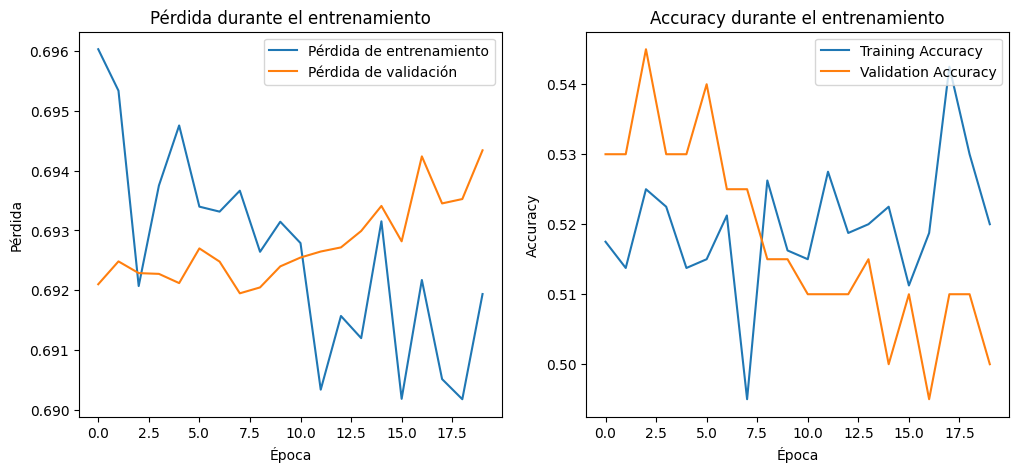

In [13]:
# Visualización de la pérdida y precisión durante el entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['loss'], label='Pérdida de entrenamiento')
ax1.plot(history.history['val_loss'], label='Pérdida de validación')
ax1.set_title('Pérdida durante el entrenamiento')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy durante el entrenamiento')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.show()

In [14]:
# Extraer datos y salidas del modelo entrenado

# Crear una capa de GRU que devuelva secuencias y estados ocultos
gru_layer = GRU(50, return_sequences=True, return_state=True)

# Datos de prueba: 5 secuencias de 10 pasos con 8 características
test_input = tf.random.normal((5, 10, 8))  # 5 secuencias, 10 pasos, 8 características
outputs, final_state = gru_layer(test_input)

print(f"Salidas de todos los pasos: {outputs.shape}")
print(f"Estado oculto final: {final_state.shape}")

Salidas de todos los pasos: (5, 10, 50)
Estado oculto final: (5, 50)


# Ejercicio práctico

In [15]:
# Generar datos sintéticos (onda senoidal con ruido) para entrenamiento
np.random.seed(SEED)
t = np.linspace(0, 100, 1000)
data = np.sin(t) + 0.1 * np.random.randn(len(t))


# Normalizar los datos
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# Crear secuencias para entrenamiento
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


seq_length = 20
X, y = create_sequences(data_scaled, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))  # (samples, timesteps, features)

# Dividir en conjunto de entrenamiento y prueba
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [16]:
# Construir modelo GRU
model = Sequential([
    GRU(50, activation='tanh', recurrent_activation='sigmoid', return_sequences=True, input_shape=(seq_length, 1)),
    GRU(30, activation='tanh', recurrent_activation='sigmoid'),
    Dense(1)  # Capa de salida para regresión
])

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 20, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 30)             │         7,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0513 - val_loss: 0.0213
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0143 - val_loss: 0.0101
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0091 - val_loss: 0.0079
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0071 - val_loss: 0.0064
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

In [20]:
# Evaluar el modelo en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


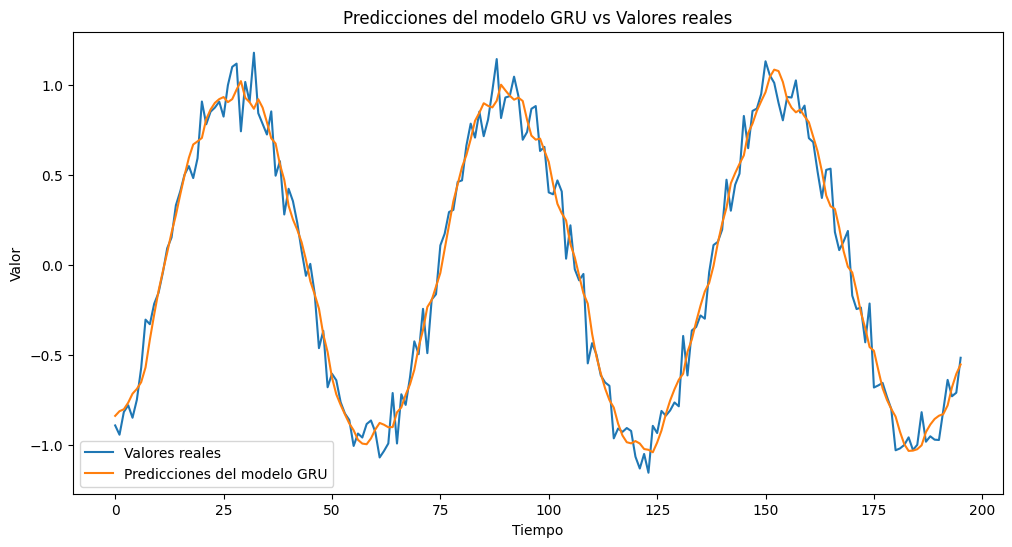

In [21]:
# Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Valores reales')
plt.plot(y_pred_inv, label='Predicciones del modelo GRU')
plt.title('Predicciones del modelo GRU vs Valores reales')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [22]:
print(f"Error cuadrático medio (MSE) en el conjunto de prueba: {np.mean((y_pred_inv - y_test_inv) ** 2):.4f}")

Error cuadrático medio (MSE) en el conjunto de prueba: 0.0133
